# Peramalan Harga Saham INDF — CNN-BiLSTM
**Revisi sesuai bimbingan 20-04-2026**

Perubahan dari versi sebelumnya:
- Grid parameter diperluas ke 3 nilai (16, 32, 64) untuk insight lebih kaya
- Dropout: [0.1, 0.2, 0.3] (3 nilai)
- Layer BiLSTM: [1, 2] (tetap)
- EPOCHS = 30 + EarlyStopping (val loss rata-rata sudah flat sebelum epoch 30)
- Windowing dilakukan dari data gabungan agar konteks antar segmen terjaga
- Normalisasi tidak perlu dipakai ----> belum diganti (diperlukan untuk kestabilan training deep learning)
- Inverse transform digunakan untuk mengembalikan prediksi ke satuan Rupiah
- Visualisasi prediksi vs aktual: hanya 1 grafik terbaik
- Label kategori akurasi (Sangat Akurat/Akurat) dihapus

## CELL 1 — Pra-Pemrosesan Data

--- ANALISIS AWAL DATA MENTAH ---
Total Hari Kerja Seharusnya : 2609 hari
Total Data Tersedia         : 2415 hari
Jumlah Data Hilang          : 194 hari


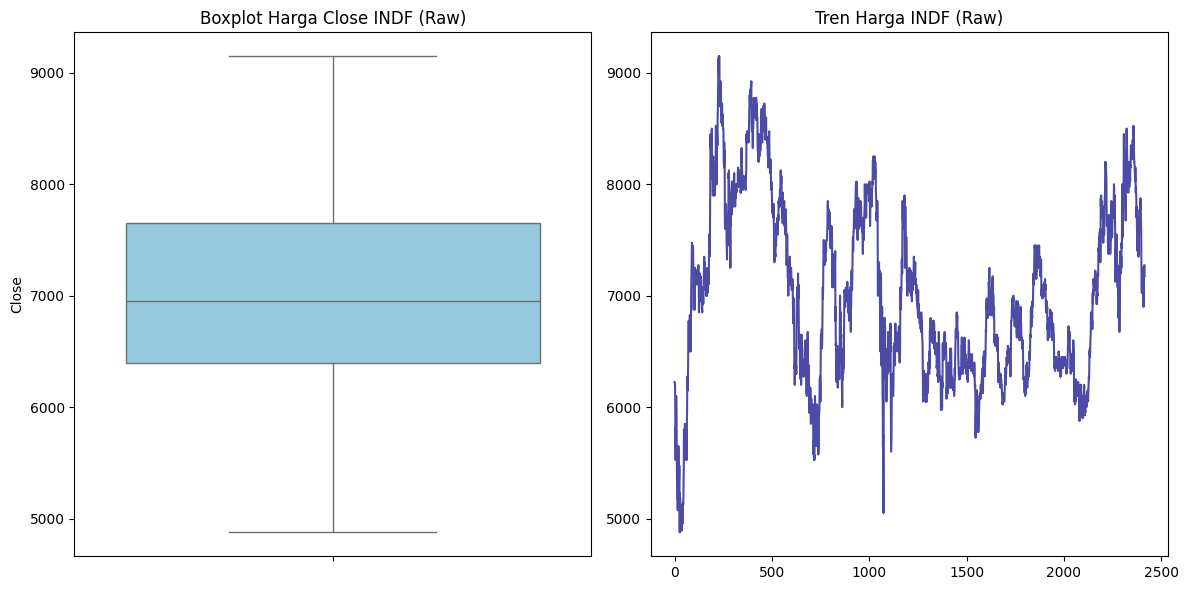


--- HASIL DETEKSI OUTLIER ---
Q1: 6400.0 | Q3: 7650.0 | IQR: 1250.0
Batas Bawah: 4525.0 | Batas Atas: 9525.0
Jumlah Outliers Terdeteksi: 0

✅ Tidak ditemukan outliers pada data mentah.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA & STANDARISASI KOLOM
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df = df_raw[['Tanggal', 'Terakhir']].rename(columns={'Tanggal': 'Date', 'Terakhir': 'Close'})

# 2. FORMAT TANGGAL & SORTIR
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
df = df.drop_duplicates(subset=['Date'], keep='first')

# 3. IDENTIFIKASI MISSING VALUES (Business Days)
all_business_days = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='B')
missing_dates = all_business_days.difference(df['Date'])

print(f"--- ANALISIS AWAL DATA MENTAH ---")
print(f"Total Hari Kerja Seharusnya : {len(all_business_days)} hari")
print(f"Total Data Tersedia         : {len(df)} hari")
print(f"Jumlah Data Hilang          : {len(missing_dates)} hari")

# 4. DETEKSI OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=df['Close'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Harga Close INDF (Raw)')
axes[1].plot(df.index, df['Close'], color='navy', alpha=0.7)
axes[1].set_title('Tren Harga INDF (Raw)')
plt.tight_layout()
plt.show()

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print(f"\n--- HASIL DETEKSI OUTLIER ---")
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Batas Bawah: {lower_bound} | Batas Atas: {upper_bound}")
print(f"Jumlah Outliers Terdeteksi: {len(outliers)}")
if len(outliers) > 0:
    print("\nDaftar Tanggal Outliers:")
    print(outliers)
else:
    print("\n✅ Tidak ditemukan outliers pada data mentah.")

|| MEMBUAT LIST TANGGAL YANG HILANG / MISSING VALUE ||

In [2]:
import pandas as pd

# 1. Load data mentah
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'], format='%d/%m/%Y')
df_raw = df_raw.sort_values('Tanggal')

# 2. Buat rentang hari kerja (Senin-Jumat) dari tanggal awal sampai akhir
full_range = pd.date_range(start=df_raw['Tanggal'].min(), end=df_raw['Tanggal'].max(), freq='B')

# 3. Cari tanggal yang ada di kalender hari kerja tapi tidak ada di dataset
missing_dates = full_range.difference(df_raw['Tanggal'])

# 4. Tampilkan hasil dalam bentuk tabel
missing_dates_df = pd.DataFrame(missing_dates, columns=['Tanggal_Kosong'])
missing_dates_df['Hari'] = missing_dates_df['Tanggal_Kosong'].dt.day_name() # Nama hari dalam Bahasa Inggris

print(f"Total Tanggal yang Hilang: {len(missing_dates_df)} hari")
print("\n--- 20 Tanggal Pertama yang Kosong ---")
print(missing_dates_df.head(20))

# Simpan ke CSV jika Anda ingin melihat daftar lengkapnya (194 hari)
missing_dates_df.to_csv('daftar_tanggal_kosong.csv', index=False)

Total Tanggal yang Hilang: 194 hari

--- 20 Tanggal Pertama yang Kosong ---
   Tanggal_Kosong       Hari
0      2015-12-09  Wednesday
1      2015-12-24   Thursday
2      2015-12-25     Friday
3      2015-12-31   Thursday
4      2016-01-01     Friday
5      2016-02-08     Monday
6      2016-03-09  Wednesday
7      2016-03-25     Friday
8      2016-05-05   Thursday
9      2016-05-06     Friday
10     2016-07-04     Monday
11     2016-07-05    Tuesday
12     2016-07-06  Wednesday
13     2016-07-07   Thursday
14     2016-07-08     Friday
15     2016-08-17  Wednesday
16     2016-09-12     Monday
17     2016-12-12     Monday
18     2016-12-26     Monday
19     2017-01-02     Monday


In [ ]:
# Install semua library yang dibutuhkan
%pip install scikit-learn tensorflow pandas numpy matplotlib seaborn 

In [3]:
from sklearn.preprocessing import MinMaxScaler

# 5. REINDEXING & INTERPOLASI
df_indexed = df.set_index('Date')
all_business_days = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq='B')
df_complete = df_indexed.reindex(all_business_days)

# Interpolasi Polinomial Ordo 2
df_complete['Close'] = df_complete['Close'].interpolate(method='polynomial', order=2)
df_complete['Close'] = df_complete['Close'].ffill().bfill()

# 6. NORMALISASI
# Catatan: Normalisasi tetap digunakan meskipun univariate karena membantu
# kestabilan gradient descent pada deep learning (nilai input terbatas 0-1).
# Hasil prediksi akan di-inverse transform kembali ke satuan Rupiah.
scaler_global = MinMaxScaler(feature_range=(0, 1))
df_complete['Close_Scaled'] = scaler_global.fit_transform(df_complete[['Close']])

# Simpan hasil
df_final = df_complete.reset_index().rename(columns={'index': 'Date'})
df_final.to_csv('INDF_Cleaned.csv', index=False)

print(f"✅ Pra-pemrosesan Selesai!")
print(f"Total Baris Akhir : {len(df_final)}")
print(f"Rentang Tanggal   : {df_final['Date'].min()} s/d {df_final['Date'].max()}")
print(f"Data disimpan ke  : 'INDF_Cleaned.csv'")
print(df_final.head())

✅ Pra-pemrosesan Selesai!
Total Baris Akhir : 2609
Rentang Tanggal   : 2015-10-23 00:00:00 s/d 2025-10-22 00:00:00
Data disimpan ke  : 'INDF_Cleaned.csv'
        Date   Close  Close_Scaled
0 2015-10-23  6225.0      0.315789
1 2015-10-26  6225.0      0.315789
2 2015-10-27  6200.0      0.309942
3 2015-10-28  6075.0      0.280702
4 2015-10-29  5650.0      0.181287


## CELL 3 — Load Data & Fungsi Windowing

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values   # Gunakan harga asli (Rupiah)

# Parameter tetap
WINDOW_SIZE = 30

def create_window_dataset(dataset, lookback):
    """Membuat pasangan (X, y) dari data time series dengan sliding window."""
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    """
    Membagi data, normalisasi, lalu windowing dari data gabungan
    agar konteks antar segmen (train→val→test) tetap terjaga.

    Alur:
      1. Split data mentah (Close) → train / val / test
      2. Fit scaler HANYA pada train → transform val & test
      3. Gabungkan kembali → window dari full scaled
      4. Potong window hasil menjadi 3 bagian sesuai proporsi
    """
    label = f"{int(ratio_train*100)}-{int(ratio_val*100)}-{int(ratio_test*100)}"
    print(f"\n>>> MEMPERSIAPKAN SKENARIO {label} ...")

    n       = len(data_full)
    n_train = int(ratio_train * n)
    n_val   = int(ratio_val   * n)
    n_test  = n - n_train - n_val

    # 1. Split data mentah
    train_raw = data_full[:n_train]
    val_raw   = data_full[n_train : n_train + n_val]
    test_raw  = data_full[n_train + n_val :]

    # 2. Normalisasi — fit HANYA pada train (cegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    # 3. Gabungkan untuk windowing (konteks antar segmen terjaga)
    full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])
    X_all, y_all = create_window_dataset(full_scaled, WINDOW_SIZE)

    # 4. Potong kembali sesuai proporsi
    # Jumlah window yang "dimiliki" tiap segmen:
    #   - Train menghasilkan (n_train - WINDOW_SIZE) window
    #   - Val & Test masing-masing menghasilkan n_val dan n_test window
    #     (mereka "meminjam" WINDOW_SIZE terakhir dari segmen sebelumnya sebagai konteks)
    n_train_w = n_train - WINDOW_SIZE
    n_val_w   = n_val
    # n_test_w  = n_test (sisa)

    X_train = X_all[:n_train_w]
    y_train = y_all[:n_train_w]

    X_val   = X_all[n_train_w : n_train_w + n_val_w]
    y_val   = y_all[n_train_w : n_train_w + n_val_w]

    X_test  = X_all[n_train_w + n_val_w :]
    y_test  = y_all[n_train_w + n_val_w :]

    print(f"   Total data      : {n} baris")
    print(f"   Train (mentah)  : {n_train} | Val: {n_val} | Test: {n_test}")
    print(f"   Shape X_train   : {X_train.shape}")
    print(f"   Shape X_val     : {X_val.shape}")
    print(f"   Shape X_test    : {X_test.shape}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
        'scaler' : scaler
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    datasets[nama] = jalankan_skenario(r_train, r_val, r_test)

print("\n✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']")


>>> MEMPERSIAPKAN SKENARIO 80-10-10 ...
   Total data      : 2609 baris
   Train (mentah)  : 2087 | Val: 260 | Test: 262
   Shape X_train   : (2057, 30, 1)
   Shape X_val     : (260, 30, 1)
   Shape X_test    : (262, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 70-15-15 ...
   Total data      : 2609 baris
   Train (mentah)  : 1826 | Val: 391 | Test: 392
   Shape X_train   : (1796, 30, 1)
   Shape X_val     : (391, 30, 1)
   Shape X_test    : (392, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 60-20-20 ...
   Total data      : 2609 baris
   Train (mentah)  : 1565 | Val: 521 | Test: 523
   Shape X_train   : (1535, 30, 1)
   Shape X_val     : (521, 30, 1)
   Shape X_test    : (523, 30, 1)

✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']


## CELL 5 - Definisi Arsitektur Model CNN-BiLSTM

In [17]:
# ============================================================
# CELL 5 — DEFINISI ARSITEKTUR MODEL CNN-BiLSTM
# ============================================================
# Lanjutan dari cell pembagian dataset (datasets sudah tersedia)

import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Bidirectional,
                                     LSTM, Dense, Dropout, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

# ----------------------------------------------------------
# FUNGSI BANGUN MODEL CNN-BiLSTM
# Parameter yang bisa di-tuning:
#   - n_filters     : jumlah filter Conv1D
#   - n_units       : jumlah unit BiLSTM per layer
#   - n_bilstm_layers : jumlah layer BiLSTM (1 atau 2)
#   - dropout_rate  : dropout untuk regularisasi
# ----------------------------------------------------------
def bangun_model(window_size, n_filters, n_units, n_bilstm_layers, dropout_rate):
    """
    Membangun model CNN-BiLSTM.
    Arsitektur:
      Conv1D → MaxPooling1D → Dropout
      → BiLSTM (1 atau 2 layer)
      → Dense(1) output
    """
    model = Sequential(name=f"CNN_BiLSTM_f{n_filters}_u{n_units}_l{n_bilstm_layers}")

    # === LAYER CNN — ekstrak pola lokal jangka pendek ===
    model.add(Conv1D(filters=n_filters,
                     kernel_size=3,
                     activation='relu',
                     padding='same',
                     input_shape=(window_size, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(dropout_rate))


    # === LAYER BiLSTM — tangkap dependensi temporal dua arah ===
    if n_bilstm_layers == 1:
        model.add(Bidirectional(LSTM(n_units, return_sequences=False)))
        model.add(Dropout(dropout_rate))
    else:
        model.add(Bidirectional(LSTM(n_units, return_sequences=True)))
        model.add(Dropout(dropout_rate))
        model.add(Bidirectional(LSTM(n_units // 2, return_sequences=False)))
        model.add(Dropout(dropout_rate))

    # === OUTPUT LAYER ===
    model.add(Dense(1))

    # Compile dengan optimizer Adam & loss MSE (sesuai proposal)
    model.compile(optimizer='adam', loss='mse')
    
    return model

def hitung_metrik(y_true_scaled, y_pred_scaled, scaler):
    """
    Menghitung MAE, RMSE, MAPE, R2 setelah inverse transform
    sehingga metrik dalam satuan asli (Rupiah).
    """
    # Inverse transform: kembalikan ke satuan Rupiah
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    
    return mae, rmse, mape, r2


print("✅ Fungsi model dan metrik siap digunakan.")


✅ Fungsi model dan metrik siap digunakan.


## CELL 6 — Hyperparameter Tuning (Grid Search)

**Revisi grid parameter:**
- `n_filters` & `n_units` → 3 nilai [16, 32, 64] agar insight lebih kaya (bukan linier)
- `dropout_rate` → [0.1, 0.2, 0.3] (3 nilai)
- `n_bilstm_layers` → [1, 2] (tetap)
- `batch_size` → [16, 32, 64] (3 nilai, diuji bersamaan untuk hasil komprehensif)
- 3 × 3 × 2 × 3 × 3 = 162 kombinasi × 3 skenario = **486 kombinasi**

In [ ]:
from itertools import product
import os

os.makedirs('models', exist_ok=True)

# --- GRID PARAMETER ---
param_grid = {
    'n_filters'       : [16, 32, 64],
    'n_units'         : [16, 32, 64],
    'n_bilstm_layers' : [1, 2],
    'dropout_rate'    : [0.1, 0.2, 0.3],
    'batch_size'      : [16, 32, 64],
}

EPOCHS   = 30
PATIENCE = 10

skenario_list  = ['80-10-10', '70-15-15', '60-20-20']
kombinasi      = list(product(
    param_grid['n_filters'],
    param_grid['n_units'],
    param_grid['n_bilstm_layers'],
    param_grid['dropout_rate'],
    param_grid['batch_size'],
))

total_kombi    = len(kombinasi)
total_skenario = len(skenario_list)
total_run      = total_kombi * total_skenario

print("=" * 70)
print("  HYPERPARAMETER TUNING CNN-BiLSTM")
print(f"  {total_kombi} kombinasi x {total_skenario} skenario = {total_run} total run")
print("=" * 70)

hasil_tuning = []

for nama_skenario in skenario_list:
    data    = datasets[nama_skenario]
    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']
    X_test  = data['X_test']
    y_test  = data['y_test']
    scaler  = data['scaler']

    print(f"\n>>> SKENARIO {nama_skenario}")
    print("-" * 70)

    for idx, (n_filters, n_units, n_layers, dropout, batch_size) in enumerate(kombinasi, 1):
        nama = f"f{n_filters}_u{n_units}_l{n_layers}_d{int(dropout*10)}_b{batch_size}"
        print(f"  [{idx:03d}/{total_kombi}] {nama} ...", end=' ')

        model = bangun_model(
            window_size     = WINDOW_SIZE,
            n_filters       = n_filters,
            n_units         = n_units,
            n_bilstm_layers = n_layers,
            dropout_rate    = dropout
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=0
        )

        waktu_mulai = time.time()
        history = model.fit(
            X_train, y_train,
            epochs          = EPOCHS,
            batch_size      = batch_size,
            validation_data = (X_val, y_val),
            callbacks       = [early_stop],
            verbose         = 0
        )
        durasi_detik   = time.time() - waktu_mulai
        epoch_berhenti = len(history.history['loss'])

        y_pred = model.predict(X_test, verbose=0)
        mae, rmse, mape, r2= hitung_metrik(y_test, y_pred, scaler)

        hasil_tuning.append({
            'Nama'          : nama,
            'Skenario'      : nama_skenario,
            'Filter CNN'    : n_filters,
            'Unit BiLSTM'   : n_units,
            'Layer BiLSTM'  : n_layers,
            'Dropout'       : dropout,
            'Batch Size'    : batch_size,
            'Epoch Berhenti': epoch_berhenti,
            'Waktu (detik)' : round(durasi_detik, 2),
            'MAE'           : round(mae, 4),
            'RMSE'          : round(rmse, 4),
            'MAPE (%)'      : round(mape, 4),
            'R2'            : round(r2, 4),   
        })

        print(f"Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | MAPE: {mape:.4f}% | R2: {r2:.4f}")

df_tuning = pd.DataFrame(hasil_tuning)
df_tuning.to_csv('hasil_tuning_CNN_BiLSTM.csv', index=False)

# --- REKAP TOP 1 PER SKENARIO ---
print("\n" + "=" * 70)
print("  TOP 1 KONFIGURASI PER SKENARIO")
print("=" * 70)
top1_per_skenario = {}
for nama_skenario in skenario_list:
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = subset.loc[subset['MAPE (%)'].idxmin()]
    top1_per_skenario[nama_skenario] = top1
    print(f"  {nama_skenario} -> {top1['Nama']} | "
          f"MAE: {top1['MAE']} | RMSE: {top1['RMSE']} | MAPE: {top1['MAPE (%)']}%")

# --- TOP 1 KESELURUHAN ---
best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]
print("\n" + "=" * 70)
print("  KONFIGURASI TERBAIK KESELURUHAN")
print("=" * 70)
print(f"  Nama         : {best_overall['Nama']}")
print(f"  Skenario     : {best_overall['Skenario']}")
print(f"  Filter CNN   : {int(best_overall['Filter CNN'])}")
print(f"  Unit BiLSTM  : {int(best_overall['Unit BiLSTM'])}")
print(f"  Layer BiLSTM : {int(best_overall['Layer BiLSTM'])}")
print(f"  Dropout      : {best_overall['Dropout']}")
print(f"  Batch Size   : {int(best_overall['Batch Size'])}")
print(f"  MAE          : {best_overall['MAE']}")
print(f"  RMSE         : {best_overall['RMSE']}")
print(f"  MAPE         : {best_overall['MAPE (%)']}%")
print("\n✅ Hasil tuning disimpan ke: 'hasil_tuning_CNN_BiLSTM.csv'")


  HYPERPARAMETER TUNING CNN-BiLSTM
  162 kombinasi x 3 skenario = 486 total run

>>> SKENARIO 80-10-10
----------------------------------------------------------------------
  [001/162] f16_u16_l1_d1_b16 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 52.64 dtk | MAPE: 2.0574%
  [002/162] f16_u16_l1_d1_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 31.40 dtk | MAPE: 1.7043%
  [003/162] f16_u16_l1_d1_b64 ... 

...

Epoch: 27 | Waktu: 47.35 dtk | MAPE: 1.3890%
  [161/162] f64_u64_l2_d3_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 34.65 dtk | MAPE: 1.3224%
  [162/162] f64_u64_l2_d3_b64 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 26.54 dtk | MAPE: 1.5357%

  TOP 1 KONFIGURASI PER SKENARIO
  80-10-10 -> f64_u64_l1_d1_b16 | MAE: 119.0156 | RMSE: 169.7035 | MAPE: 1.5549%
  70-15-15 -> f64_u64_l1_d1_b16 | MAE: 97.6948 | RMSE: 142.7956 | MAPE: 1.3255%
  60-20-20 -> f64_u64_l1_d1_b16 | MAE: 86.1557 | RMSE: 126.9862 | MAPE: 1.1942%

  KONFIGURASI TERBAIK KESELURUHAN
  Nama         : f64_u64_l1_d1_b16
  Skenario     : 60-20-20
  Filter CNN   : 64
  Unit BiLSTM  : 64
  Layer BiLSTM : 1
  Dropout      : 0.1
  Batch Size   : 16
  MAE          : 86.1557
  RMSE         : 126.9862
  MAPE         : 1.1942%

✅ Hasil tuning disimpan ke: 'hasil_tuning_CNN_BiLSTM.csv'


## CELL 7 — Visualisasi Trade-Off Tuning

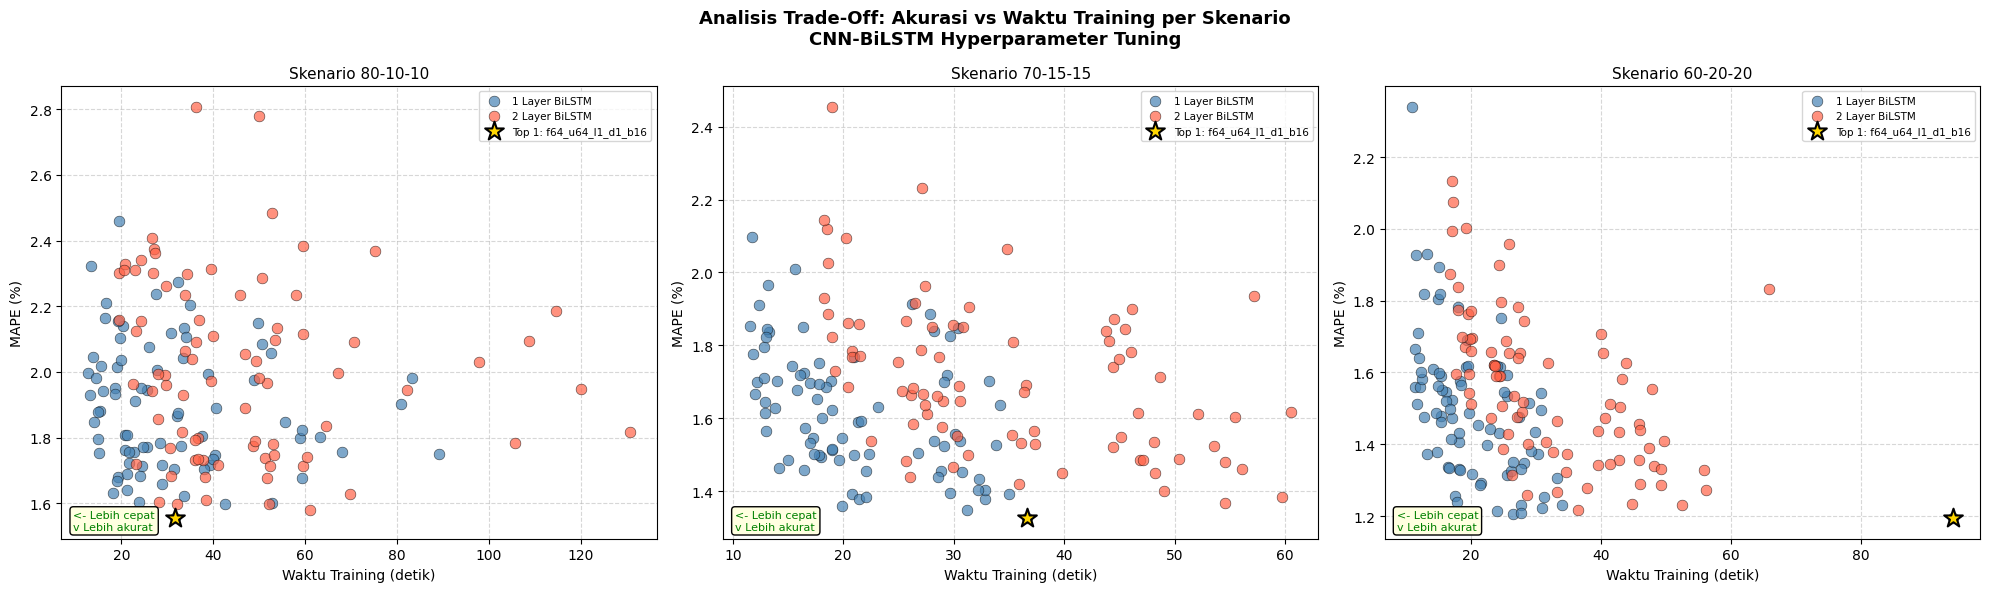

✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'


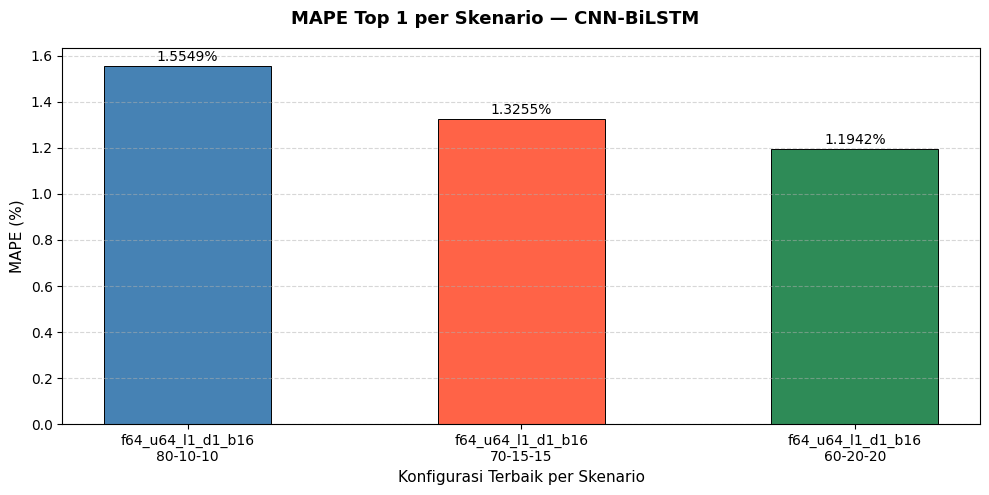

✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Analisis Trade-Off: Akurasi vs Waktu Training per Skenario\n'
    'CNN-BiLSTM Hyperparameter Tuning',
    fontsize=13, fontweight='bold'
)

colors_layer = {1: 'steelblue', 2: 'tomato'}

for col_idx, nama_skenario in enumerate(skenario_list):
    ax     = axes[col_idx]
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = top1_per_skenario[nama_skenario]

    for n_layer in [1, 2]:
        s = subset[subset['Layer BiLSTM'] == n_layer]
        ax.scatter(
            s['Waktu (detik)'], s['MAPE (%)'],
            c=colors_layer[n_layer],
            label=f'{n_layer} Layer BiLSTM',
            s=60, edgecolors='black', linewidths=0.4, alpha=0.7, zorder=3
        )

    # Highlight top 1
    ax.scatter(
        [top1['Waktu (detik)']], [top1['MAPE (%)']],
        c='gold', s=200, edgecolors='black',
        linewidths=1.5, zorder=5, marker='*',
        label=f"Top 1: {top1['Nama']}"
    )

    ax.set_title(f'Skenario {nama_skenario}', fontsize=11)
    ax.set_xlabel('Waktu Training (detik)', fontsize=10)
    ax.set_ylabel('MAPE (%)', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.annotate(
        '<- Lebih cepat\nv Lebih akurat',
        xy=(0.02, 0.02), xycoords='axes fraction',
        fontsize=8, color='green',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
    )

plt.tight_layout()
plt.savefig('tradeoff_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'")

# Bar chart top 1 per skenario
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('MAPE Top 1 per Skenario — CNN-BiLSTM', fontsize=13, fontweight='bold')

nama_list = [top1_per_skenario[s]['Nama'] + '\n' + s for s in skenario_list]
mape_list = [top1_per_skenario[s]['MAPE (%)'] for s in skenario_list]
bars      = ax.bar(nama_list, mape_list, color=['steelblue', 'tomato', 'seagreen'],
                   edgecolor='black', linewidth=0.7, width=0.5)

for bar, val in zip(bars, mape_list):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_xlabel('Konfigurasi Terbaik per Skenario', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top1_per_skenario.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'")


## CELL 8 — Training Final: 1 Konfigurasi Terbaik × 3 Skenario

Konfigurasi terbaik (MAPE terkecil dari seluruh 486 run tuning)
dijalankan ulang di 3 skenario pembagian data.

Alur:
```
Train → [Val: monitor EarlyStopping] → Test → Performa (MAE, RMSE, MAPE)
```


In [20]:
# ============================================================
# TRAINING FINAL — 1 Konfigurasi Terbaik × 3 Skenario
# ============================================================
# Konfigurasi terbaik diambil dari hasil tuning (MAPE terkecil
# dari seluruh kombinasi × seluruh skenario)

best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]

konfigurasi_terbaik = {
    'nama'           : best_overall['Nama'],
    'n_filters'      : int(best_overall['Filter CNN']),
    'n_units'        : int(best_overall['Unit BiLSTM']),
    'n_bilstm_layers': int(best_overall['Layer BiLSTM']),
    'dropout_rate'   : float(best_overall['Dropout']),
    'batch_size'     : int(best_overall['Batch Size']),
}

skenario_final = ['80-10-10', '70-15-15', '60-20-20']
EPOCHS_FINAL   = 30
PATIENCE_FINAL = 10

hasil_final   = []
history_final = {}
model_final   = {}

print("=" * 70)
print("  TRAINING FINAL CNN-BiLSTM")
print(f"  Konfigurasi: {konfigurasi_terbaik['nama']}")
print(f"  3 Skenario  : {skenario_final}")
print("=" * 70)

for nama_skenario in skenario_final:
    key  = f"{konfigurasi_terbaik['nama']}_{nama_skenario}"
    data = datasets[nama_skenario]

    print(f"\n>>> [{key}]")

    model = bangun_model(
        window_size     = WINDOW_SIZE,
        n_filters       = konfigurasi_terbaik['n_filters'],
        n_units         = konfigurasi_terbaik['n_units'],
        n_bilstm_layers = konfigurasi_terbaik['n_bilstm_layers'],
        dropout_rate    = konfigurasi_terbaik['dropout_rate'],
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE_FINAL,
        restore_best_weights=True,
        verbose=0
    )
    checkpoint = ModelCheckpoint(
        filepath=f"models/{key}.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )

    # TRAINING: belajar dari train, monitor via val
    waktu_mulai = time.time()
    history = model.fit(
        data['X_train'], data['y_train'],
        epochs          = EPOCHS_FINAL,
        batch_size      = konfigurasi_terbaik['batch_size'],
        validation_data = (data['X_val'], data['y_val']),
        callbacks       = [early_stop, checkpoint],
        verbose         = 0
    )
    durasi_detik   = time.time() - waktu_mulai
    epoch_berhenti = len(history.history['loss'])

    # EVALUASI PERFORMA: dari TEST SET
    y_pred = model.predict(data['X_test'], verbose=0)
    mae, rmse, mape, r2 = hitung_metrik(data['y_test'], y_pred, data['scaler'])

    hasil_final.append({
        'Konfigurasi'   : konfigurasi_terbaik['nama'],
        'Skenario'      : nama_skenario,
        'Epoch Berhenti': epoch_berhenti,
        'Waktu (detik)' : round(durasi_detik, 2),
        'MAE'           : round(mae, 4),
        'RMSE'          : round(rmse, 4),
        'MAPE (%)'      : round(mape, 4),
        'R2'            : round(r2, 4),
    })

    history_final[key] = history.history
    model_final[key]   = model

    print(f"    ✅ Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | "
          f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4f}% | R2: {r2:.4f}")

df_final_hasil = pd.DataFrame(hasil_final)

print("\n\n" + "=" * 70)
print("  REKAP HASIL TRAINING FINAL CNN-BiLSTM")
print("=" * 70)
print(df_final_hasil.to_string(index=False))

df_final_hasil.to_csv('hasil_training_final_CNN_BiLSTM.csv', index=False)
print("\n✅ Hasil disimpan ke: 'hasil_training_final_CNN_BiLSTM.csv'")

# Simpan variabel untuk visualisasi & prediksi
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_skenario = best_row['Skenario']
best_key      = f"{konfigurasi_terbaik['nama']}_{best_skenario}"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']
best_label    = f"CNN-BiLSTM ({konfigurasi_terbaik['nama']})"

print(f"\n🏆 Model terbaik: {best_key} | MAPE: {best_mape}%")


  TRAINING FINAL CNN-BiLSTM
  Konfigurasi: f64_u64_l1_d1_b16
  3 Skenario  : ['80-10-10', '70-15-15', '60-20-20']

>>> [f64_u64_l1_d1_b16_80-10-10]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✅ Epoch: 30 | Waktu: 75.30 dtk | MAE: 124.43 | RMSE: 173.25 | MAPE: 1.6273% | R2: 0.7944

>>> [f64_u64_l1_d1_b16_70-15-15]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✅ Epoch: 28 | Waktu: 68.07 dtk | MAE: 99.52 | RMSE: 145.37 | MAPE: 1.3494% | R2: 0.9604

>>> [f64_u64_l1_d1_b16_60-20-20]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✅ Epoch: 30 | Waktu: 62.01 dtk | MAE: 86.09 | RMSE: 129.14 | MAPE: 1.1909% | R2: 0.9693


  REKAP HASIL TRAINING FINAL CNN-BiLSTM
      Konfigurasi Skenario  Epoch Berhenti  Waktu (detik)      MAE     RMSE  MAPE (%)     R2
f64_u64_l1_d1_b16 80-10-10              30          75.30 124.4282 173.2462    1.6273 0.7944
f64_u64_l1_d1_b16 70-15-15              28          68.07  99.5243 145.3707    1.3494 0.9604
f64_u64_l1_d1_b16 60-20-20              30          62.01  86.0852 129.1388    1.1909 0.9693

✅ Hasil disimpan ke: 'hasil_training_final_CNN_BiLSTM.csv'

🏆 Model terbaik: f64_u64_l1_d1_b16_60-20-20 | MAPE: 1.1909%


## CELL 9 — Loss Curve (Training vs Validation)

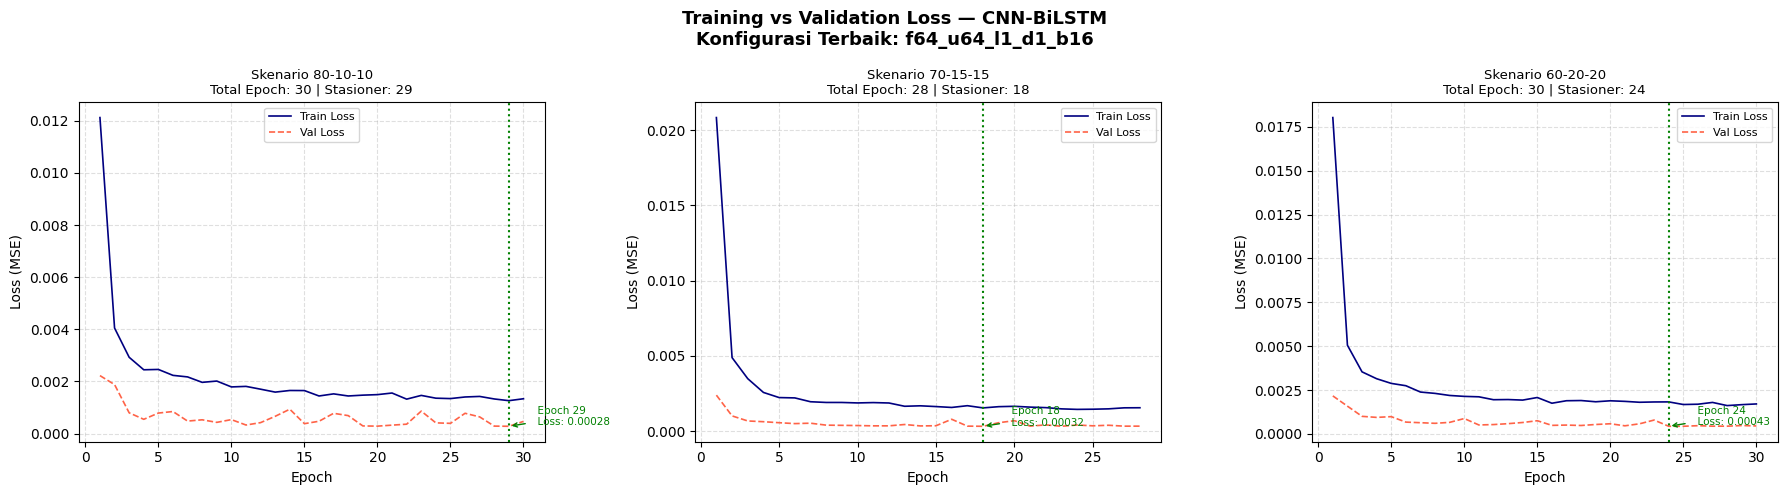

✅ Loss curve disimpan ke: 'loss_curve.png'


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Training vs Validation Loss — CNN-BiLSTM\n'
    f'Konfigurasi Terbaik: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

for col_idx, nama_skenario in enumerate(skenario_final):
    key = f"{konfigurasi_terbaik['nama']}_{nama_skenario}"
    ax  = axes[col_idx]
    h   = history_final[key]

    total_epoch   = len(h['loss'])
    val_loss_arr  = np.array(h['val_loss'])
    best_epoch    = int(np.argmin(val_loss_arr)) + 1
    best_val_loss = val_loss_arr[best_epoch - 1]

    ax.plot(range(1, total_epoch + 1), h['loss'],
            label='Train Loss', color='navy', linewidth=1.2)
    ax.plot(range(1, total_epoch + 1), h['val_loss'],
            label='Val Loss', color='tomato',
            linewidth=1.2, linestyle='--')

    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
    ax.annotate(
        f'  Epoch {best_epoch}\n  Loss: {best_val_loss:.5f}',
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + total_epoch * 0.05, best_val_loss * 1.15),
        fontsize=7.5, color='green',
        arrowprops=dict(arrowstyle='->', color='green', lw=1)
    )

    ax.set_title(
        f'Skenario {nama_skenario}\n'
        f'Total Epoch: {total_epoch} | Stasioner: {best_epoch}',
        fontsize=9.5
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve disimpan ke: 'loss_curve.png'")


## CELL 10 — Perbandingan Metrik Evaluasi (Bar Chart)

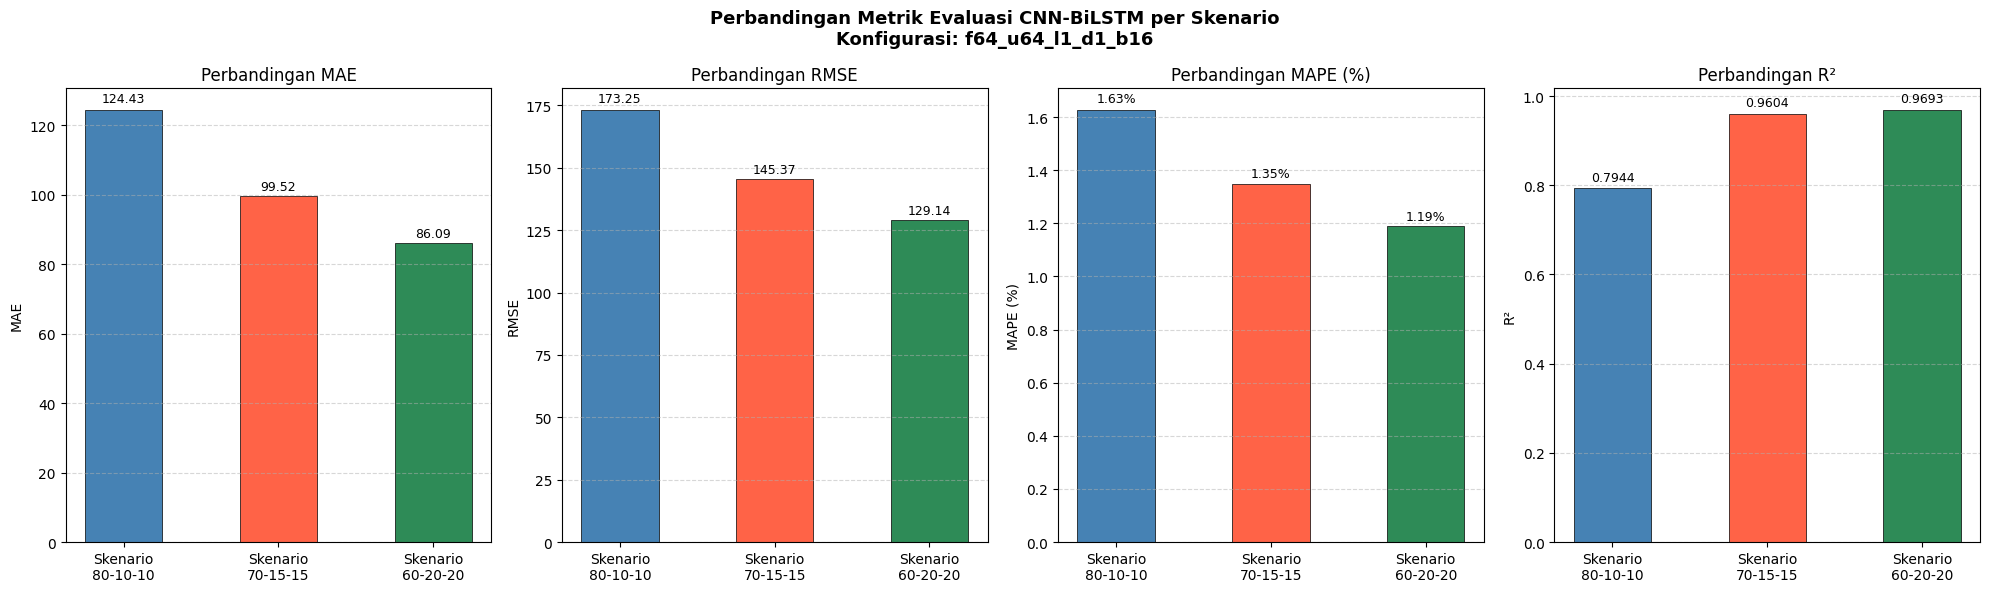


🏆 Performa terbaik:
   Skenario : 60-20-20
   MAE      : 86.09
   RMSE     : 129.14
   MAPE     : 1.1909%
   R²       : 0.9693
   Waktu Training: 62.01 detik


In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle(
    f'Perbandingan Metrik Evaluasi CNN-BiLSTM per Skenario\n'
    f'Konfigurasi: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

metrik_list  = ['MAE', 'RMSE', 'MAPE (%)', 'R2']
metrik_label = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
bar_colors   = ['steelblue', 'tomato', 'seagreen']

for i, (metrik, label) in enumerate(zip(metrik_list, metrik_label)):
    ax   = axes[i]
    vals = df_final_hasil[metrik].values

    bars = ax.bar(
        [f'Skenario\n{s}' for s in skenario_final],
        vals, color=bar_colors,
        edgecolor='black', linewidth=0.5, width=0.5
    )

    for bar, val in zip(bars, vals):
        if metrik == 'MAPE (%)':
            txt = f'{val:.2f}%'
        elif metrik == 'R2':
            txt = f'{val:.4f}'   # R² perlu 4 desimal karena nilainya 0.xxxx
        else:
            txt = f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * val,
                txt, ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label)
    ax.set_title(f'Perbandingan {label}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evaluasi_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

best_row = df_final_hasil.loc[df_final_hasil['MAPE (%)'].idxmin()]
print(f"\n🏆 Performa terbaik:")
print(f"   Skenario : {best_row['Skenario']}")
print(f"   MAE      : {best_row['MAE']:.2f}")
print(f"   RMSE     : {best_row['RMSE']:.2f}")
print(f"   MAPE     : {best_row['MAPE (%)']}%")
print(f"   R²       : {best_row['R2']:.4f}")
print(f"   Waktu Training: {best_row['Waktu (detik)']} detik")


## CELL 11 — Visualisasi Prediksi vs Aktual (1 Grafik Terbaik)

**Revisi:** Hanya menampilkan 1 grafik dari model dengan MAPE terkecil,
bukan semua 6 kombinasi.

Model terbaik: f64_u64_l1_d1_b16_60-20-20
MAE: 86.09 | RMSE: 129.14 | MAPE: 1.1909% | R2: 0.9693 | Waktu: 62.01 dtk


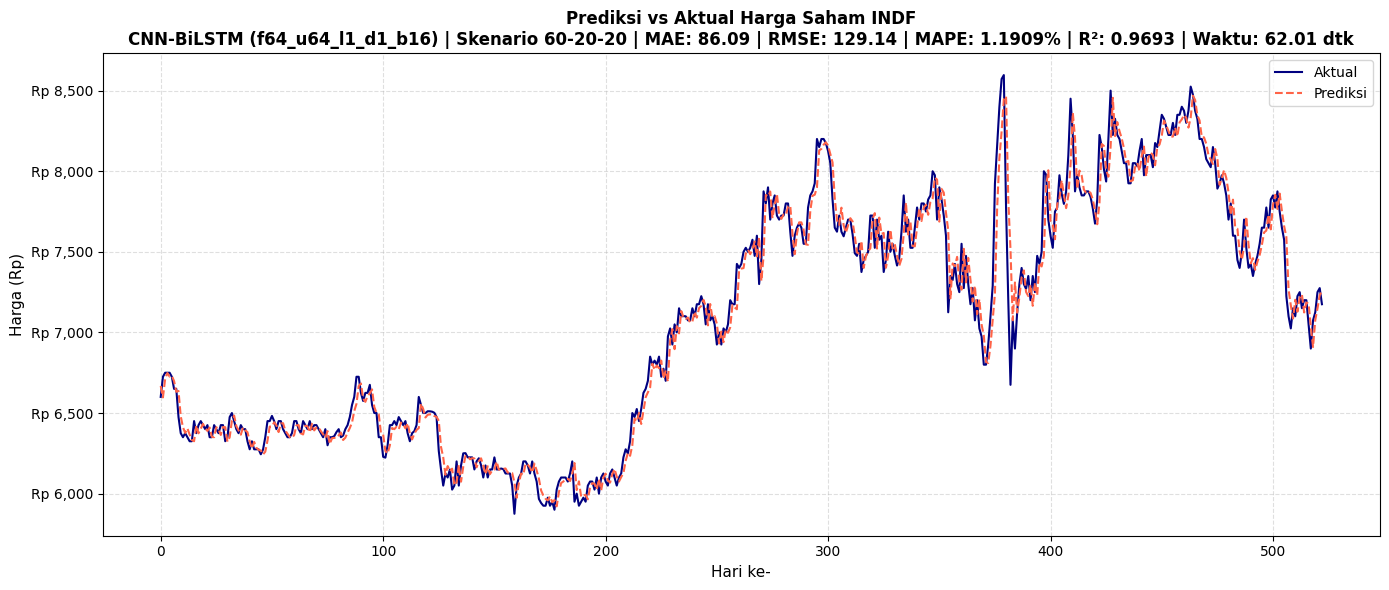

✅ Grafik prediksi disimpan ke: 'prediksi_vs_aktual_terbaik.png'


In [27]:
# Temukan model terbaik
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_key      = f"{best_row['Konfigurasi']}_{best_row['Skenario']}"
best_skenario = best_row['Skenario']
best_label    = f"CNN-BiLSTM ({best_row['Konfigurasi']})"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']
best_waktu = best_row['Waktu (detik)']

print(f"Model terbaik: {best_key}")
print(f"MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R2: {best_r2:.4f} | Waktu: {best_waktu} dtk")

data = datasets[best_skenario]

# Prediksi ulang
y_pred_scaled = model_final[best_key].predict(data['X_test'], verbose=0)

# Inverse transform → satuan Rupiah
y_true = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
y_pred = data['scaler'].inverse_transform(y_pred_scaled).flatten()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_true, label='Aktual', color='navy', linewidth=1.5)
ax.plot(y_pred, label='Prediksi', color='tomato', linewidth=1.5, linestyle='--')

ax.set_title(
    f'Prediksi vs Aktual Harga Saham INDF\n'
    f'{best_label} | Skenario {best_skenario} | '
    f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f} | Waktu: {best_waktu} dtk',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Hari ke-', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))

plt.tight_layout()
plt.savefig('prediksi_vs_aktual_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi disimpan ke: 'prediksi_vs_aktual_terbaik.png'")

## CELL 12 — Prediksi 1 Hari ke Depan (23 Oktober 2025)

Menggunakan model terbaik untuk memprediksi harga saham INDF
pada 1 hari kerja setelah data terakhir (22 Oktober 2025).

  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN
  Model            : f64_u64_l1_d1_b16_60-20-20
  Data terakhir    : 22 October 2025 | Harga Close: Rp 7,175
  Tanggal prediksi : 23 October 2025
  Prediksi Harga   : Rp 7,153.80


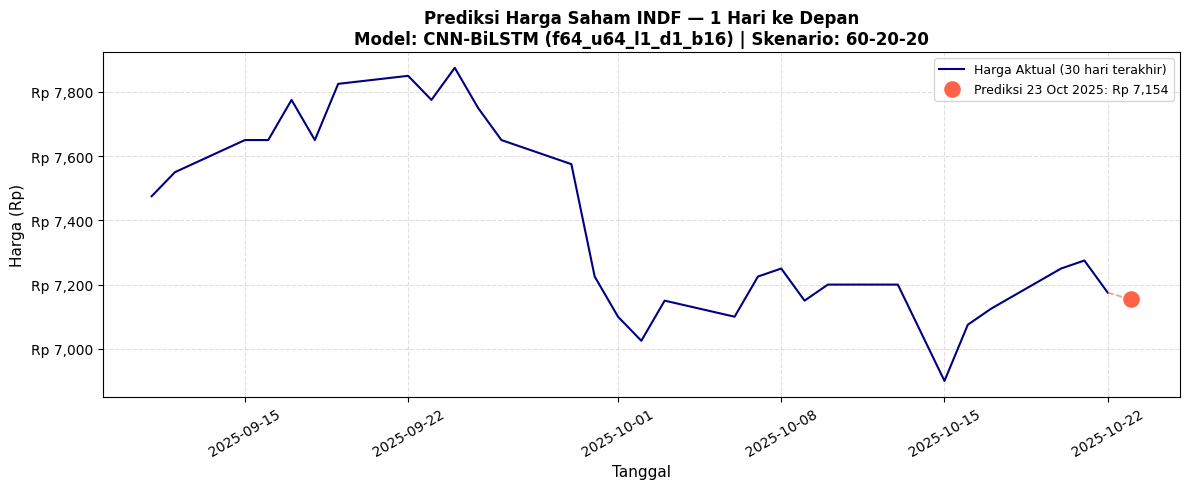

Grafik disimpan ke: 'prediksi_1hari.png'


In [24]:
# ============================================================
# CELL 12 — PREDIKSI 1 HARI KE DEPAN
# ============================================================
# Input : WINDOW_SIZE (30) data terakhir dari seluruh dataset
# Output: prediksi harga penutupan 1 hari berikutnya (dalam Rupiah)

import pandas as pd
import numpy as np

# 1. Ambil model & scaler terbaik
model_terbaik  = model_final[best_key]
scaler_terbaik = datasets[best_skenario]['scaler']

# 2. Ambil WINDOW_SIZE data terakhir dari seluruh dataset
data_close_full = df[['Close']].values          # shape (N, 1)
last_window_raw = data_close_full[-WINDOW_SIZE:] # shape (30, 1)

# 3. Normalisasi menggunakan scaler yang sudah di-fit pada train set
last_window_scaled = scaler_terbaik.transform(last_window_raw)

# 4. Reshape ke format (1, WINDOW_SIZE, 1)
X_pred_1hari = last_window_scaled.reshape(1, WINDOW_SIZE, 1)

# 5. Prediksi (output skala 0-1)
pred_scaled = model_terbaik.predict(X_pred_1hari, verbose=0)

# 6. Inverse transform → satuan Rupiah
pred_rupiah = scaler_terbaik.inverse_transform(pred_scaled)[0][0]

# 7. Tentukan tanggal prediksi (1 hari kerja setelah data terakhir)
tanggal_terakhir = df.index[-1]
tanggal_prediksi = tanggal_terakhir + pd.offsets.BDay(1)

print("=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN")
print("=" * 55)
print(f"  Model            : {best_key}")
print(f"  Data terakhir    : {tanggal_terakhir.strftime('%d %B %Y')} "
      f"| Harga Close: Rp {data_close_full[-1][0]:,.0f}")
print(f"  Tanggal prediksi : {tanggal_prediksi.strftime('%d %B %Y')}")
print(f"  Prediksi Harga   : Rp {pred_rupiah:,.2f}")
print("=" * 55)

# Visualisasi: 30 hari historis + 1 titik prediksi
fig, ax = plt.subplots(figsize=(12, 5))

tanggal_historis = df.index[-WINDOW_SIZE:]
harga_historis   = data_close_full[-WINDOW_SIZE:].flatten()

ax.plot(tanggal_historis, harga_historis,
        label='Harga Aktual (30 hari terakhir)',
        color='navy', linewidth=1.5)

label_pred = f"Prediksi {tanggal_prediksi.strftime('%d %b %Y')}: Rp {pred_rupiah:,.0f}"
ax.scatter([tanggal_prediksi], [pred_rupiah],
           color='tomato', s=120, zorder=5, label=label_pred)

ax.plot([tanggal_historis[-1], tanggal_prediksi],
        [harga_historis[-1], pred_rupiah],
        color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_title(
    f'Prediksi Harga Saham INDF — 1 Hari ke Depan\n'
    f'Model: {best_label} | Skenario: {best_skenario}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_1hari.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan ke: 'prediksi_1hari.png'")



## CELL 13 — Prediksi 30 Hari ke Depan (Recursive)

Strategi recursive forecasting:
- Hasil prediksi hari ke-N dianggap sebagai data aktual
- Digunakan sebagai input untuk prediksi hari ke-N+1
- Contoh: prediksi 23 Okt → dianggap aktual → input untuk prediksi 24 Okt → dst
- Total 30 hari kerja ke depan setelah 22 Oktober 2025.

  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN
  Model    : f64_u64_l1_d1_b16_60-20-20
  Strategi : Recursive Forecasting
  Mulai    : 23 October 2025
  Selesai  : 03 December 2025
         Tanggal  Prediksi (Rp)
 23 October 2025    7153.799805
 24 October 2025    7149.390137
 27 October 2025    7144.979980
 28 October 2025    7142.189941
 29 October 2025    7130.939941
 30 October 2025    7112.879883
 31 October 2025    7096.450195
03 November 2025    7069.870117
04 November 2025    7051.629883
05 November 2025    7022.830078
06 November 2025    7003.450195
07 November 2025    6978.640137
10 November 2025    6962.759766
11 November 2025    6945.520020
12 November 2025    6932.930176
13 November 2025    6915.569824
14 November 2025    6899.279785
17 November 2025    6878.990234
18 November 2025    6861.419922
19 November 2025    6840.870117
20 November 2025    6825.580078
21 November 2025    6807.250000
24 November 2025    6792.819824
25 November 2025    6778.450195
26 November 2025   

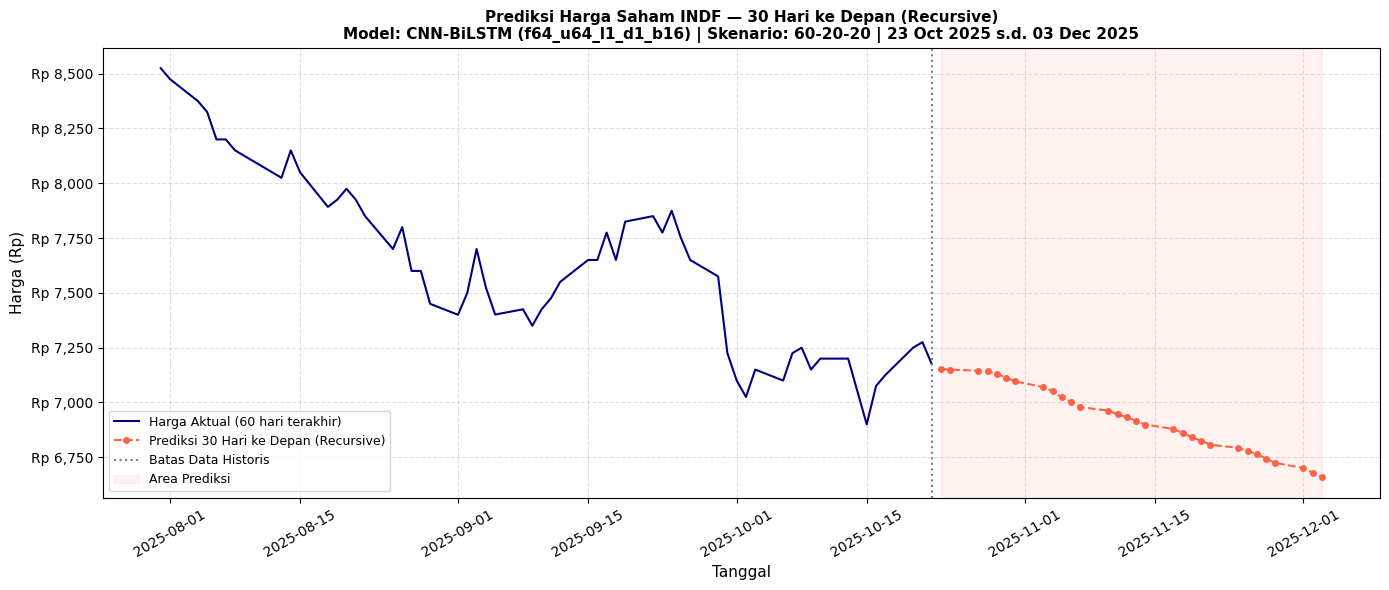

✅ Grafik disimpan ke: 'prediksi_30hari.png'


In [25]:
# ============================================================
# CELL 13 — PREDIKSI 30 HARI KE DEPAN (RECURSIVE FORECASTING)
# ============================================================
# Strategi recursive:
#   - Prediksi hari ke-1 (23 Okt) dianggap sebagai data aktual
#   - Masukkan ke window → prediksi hari ke-2 (24 Okt) → dst
#   - Error bisa terakumulasi semakin jauh prediksi

DAYS_AHEAD = 30

# 1. Window awal: 30 data terakhir (sudah dinormalisasi, dari Cell 12)
current_window = last_window_scaled.copy()  # shape (30, 1)

# 2. Prediksi rekursif
prediksi_list = []

for hari in range(DAYS_AHEAD):
    # Reshape ke (1, WINDOW_SIZE, 1)
    X_input = current_window.reshape(1, WINDOW_SIZE, 1)

    # Prediksi 1 langkah ke depan
    pred = model_terbaik.predict(X_input, verbose=0)[0][0]  # skala 0-1
    prediksi_list.append(pred)

    # Hasil prediksi dianggap aktual → geser window
    new_point      = np.array([[pred]])
    current_window = np.concatenate([current_window[1:], new_point], axis=0)

# 3. Inverse transform → satuan Rupiah
prediksi_scaled_arr = np.array(prediksi_list).reshape(-1, 1)
prediksi_rupiah_arr = scaler_terbaik.inverse_transform(prediksi_scaled_arr).flatten()

# 4. Buat daftar tanggal prediksi (hari kerja)
tanggal_awal = tanggal_terakhir + pd.offsets.BDay(1)
tanggal_pred = pd.date_range(start=tanggal_awal, periods=DAYS_AHEAD, freq='B')

# 5. Simpan ke DataFrame & CSV
df_prediksi_30 = pd.DataFrame({
    'Tanggal'       : tanggal_pred.strftime('%d %B %Y'),
    'Prediksi (Rp)' : prediksi_rupiah_arr.round(2)
})

print("=" * 50)
print("  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN")
print("=" * 50)
print(f"  Model    : {best_key}")
print(f"  Strategi : Recursive Forecasting")
print(f"  Mulai    : {tanggal_pred[0].strftime('%d %B %Y')}")
print(f"  Selesai  : {tanggal_pred[-1].strftime('%d %B %Y')}")
print("=" * 50)
print(df_prediksi_30.to_string(index=False))

df_prediksi_30.to_csv('prediksi_30hari_INDF.csv', index=False)
print("\n✅ Hasil disimpan ke: 'prediksi_30hari_INDF.csv'")

# 6. Visualisasi: 60 hari historis + 30 hari prediksi
LOOKBACK_VIS     = 60
tanggal_hist_vis = df.index[-LOOKBACK_VIS:]
harga_hist_vis   = data_close_full[-LOOKBACK_VIS:].flatten()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(tanggal_hist_vis, harga_hist_vis,
        label='Harga Aktual (60 hari terakhir)',
        color='navy', linewidth=1.5)

ax.plot(tanggal_pred, prediksi_rupiah_arr,
        label='Prediksi 30 Hari ke Depan (Recursive)',
        color='tomato', linewidth=1.5,
        linestyle='--', marker='o', markersize=4)

ax.axvline(x=tanggal_terakhir, color='gray',
           linestyle=':', linewidth=1.5, label='Batas Data Historis')

ax.axvspan(tanggal_pred[0], tanggal_pred[-1],
           alpha=0.08, color='tomato', label='Area Prediksi')

tgl_mulai   = tanggal_pred[0].strftime('%d %b %Y')
tgl_selesai = tanggal_pred[-1].strftime('%d %b %Y')
ax.set_title(
    f'Prediksi Harga Saham INDF — 30 Hari ke Depan (Recursive)\n'
    f'Model: {best_label} | Skenario: {best_skenario} | '
    f'{tgl_mulai} s.d. {tgl_selesai}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_30hari.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan ke: 'prediksi_30hari.png'")


In [1]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib
import sklearn
print(f"Python      : cek di terminal dengan 'python --version'")
print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

Python      : cek di terminal dengan 'python --version'
TensorFlow  : 2.19.0
Keras       : 3.10.0
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.7
Scikit-learn: 1.8.0
